                                               Tweet  polarity  \
0  Hand-Held ���Hobo�۪: Drafthouse launches ���Ho...  0.000000   
1  Again? RT @mention Line at the Apple store is ... -1.000000   
2  Boooo! RT @mention Flipboard is developing an ...  0.000000   
3  Thanks to @mention for publishing the news of ...  0.112121   
4  ���@mention &quot;Apple has opened a pop-up st...  0.118182   

  predicted_sentiment  
0             Neutral  
1            Negative  
2             Neutral  
3            Positive  
4            Positive  


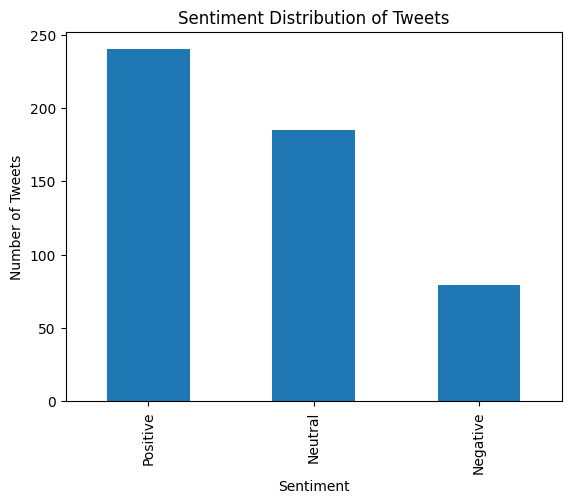

In [ ]:
# Import libraries
import pandas as pd
from textblob import TextBlob


# Load dataset
data = pd.read_csv("dataset-sentiment.csv")

# Create empty list for polarity scores
polarity_list = []

# Loop through each  tweet
for tweet in data["Tweet"]:
    
    analysis = TextBlob(str(tweet))
    polarity = analysis.sentiment.polarity
    
    polarity_list.append(polarity)

# Add polarity column to dataset
data["polarity"] = polarity_list

# Create sentiment label list
sentiment_list = []

for score in data["polarity"]:
    
    if score > 0:
        sentiment_list.append("Positive")
    elif score == 0:
        sentiment_list.append("Neutral")
    else:
        sentiment_list.append("Negative")

# Add predicted sentiment column
data["predicted_sentiment"] = sentiment_list

# Show first rows of dataset
print(data.head())

# Save results to new CSV
data.to_csv("sentiment_results.csv", index=False)

import matplotlib.pyplot as plt

# Count sentiments
sentiment_counts = data["predicted_sentiment"].value_counts()

# Plot bar chart
plt.figure()
sentiment_counts.plot(kind="bar")

# Labels
plt.title("Sentiment Distribution of Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

# Show plot
plt.show()
